In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
torch.set_default_dtype(torch.float64)

def set_BCs(T):
    T[0]  = T[1]                              # Left boundary (Neumann)
    T[-1] = T[-2]**2 / max(T[-3], 1e-40)     # Right boundary


In [22]:
def solve_two_layer_CN(k1, k2, z_dis, Pda, Lz, nz, tf, Delta_d, device):
    # spatial grid
    dz = Lz / nz
    z  = torch.arange(-0.5, nz + 1, device=device) * dz   # (nz+2,)
    zh = 0.5 * (z[:-1] + z[1:])                           # (nz+1,)

    # interface setup
    m = torch.searchsorted(z, z_dis, right=True).item() - 1
    k_interface = 2 * k1 * k2 / (k1 + k2)
    kh = torch.where(z[:-1] < z_dis,
                     torch.tensor(k1, device=device),
                     torch.tensor(k2, device=device))
    kh[m] = k_interface

    dt_stab = 0.5 * (dz**2) / max(k1, k2)
    n_sub_t = int(np.ceil(Delta_d / dt_stab))
    dt      = Delta_d / n_sub_t
    print(f'n_sub_t={n_sub_t}, dt={dt:.4e}')

    source = Pda * torch.exp(-z[1:-1])

    T      = torch.zeros(nz + 2, device=device)
    U_list = []
    t_list = []

    for step in range(n_sub_t):
        set_BCs(T)
        Jh = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source
        U_list.append(T.clone())
        t_list.append((step + 1) * dt)

    t_out = torch.tensor(t_list, device=device)
    U     = torch.stack(U_list, dim=1)    # (nz+2, n_sub_t)
    return z, zh, t_out, U

## Run the solver

In [26]:
device = 'cpu'
k1 = 1.0; k2 = 2.0; z_dis = 0.50; Pda = 1.0; tf = 2.0
Lz = 10.0; nz_unit = 10; nz = int(Lz) * nz_unit

Delta_d = 1.0 / 4.0   # chosen so n_sub_t ≈ nz

z, zh, t_out, U = solve_two_layer_CN(k1, k2, z_dis, Pda, Lz, nz, tf, Delta_d, device)
print(f'U shape: {U.shape}')   # should be (nz+2, nt) ≈ square

n_sub_t=100, dt=2.5000e-03
U shape: torch.Size([102, 100])


/tmp/ipykernel_332/3180825632.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


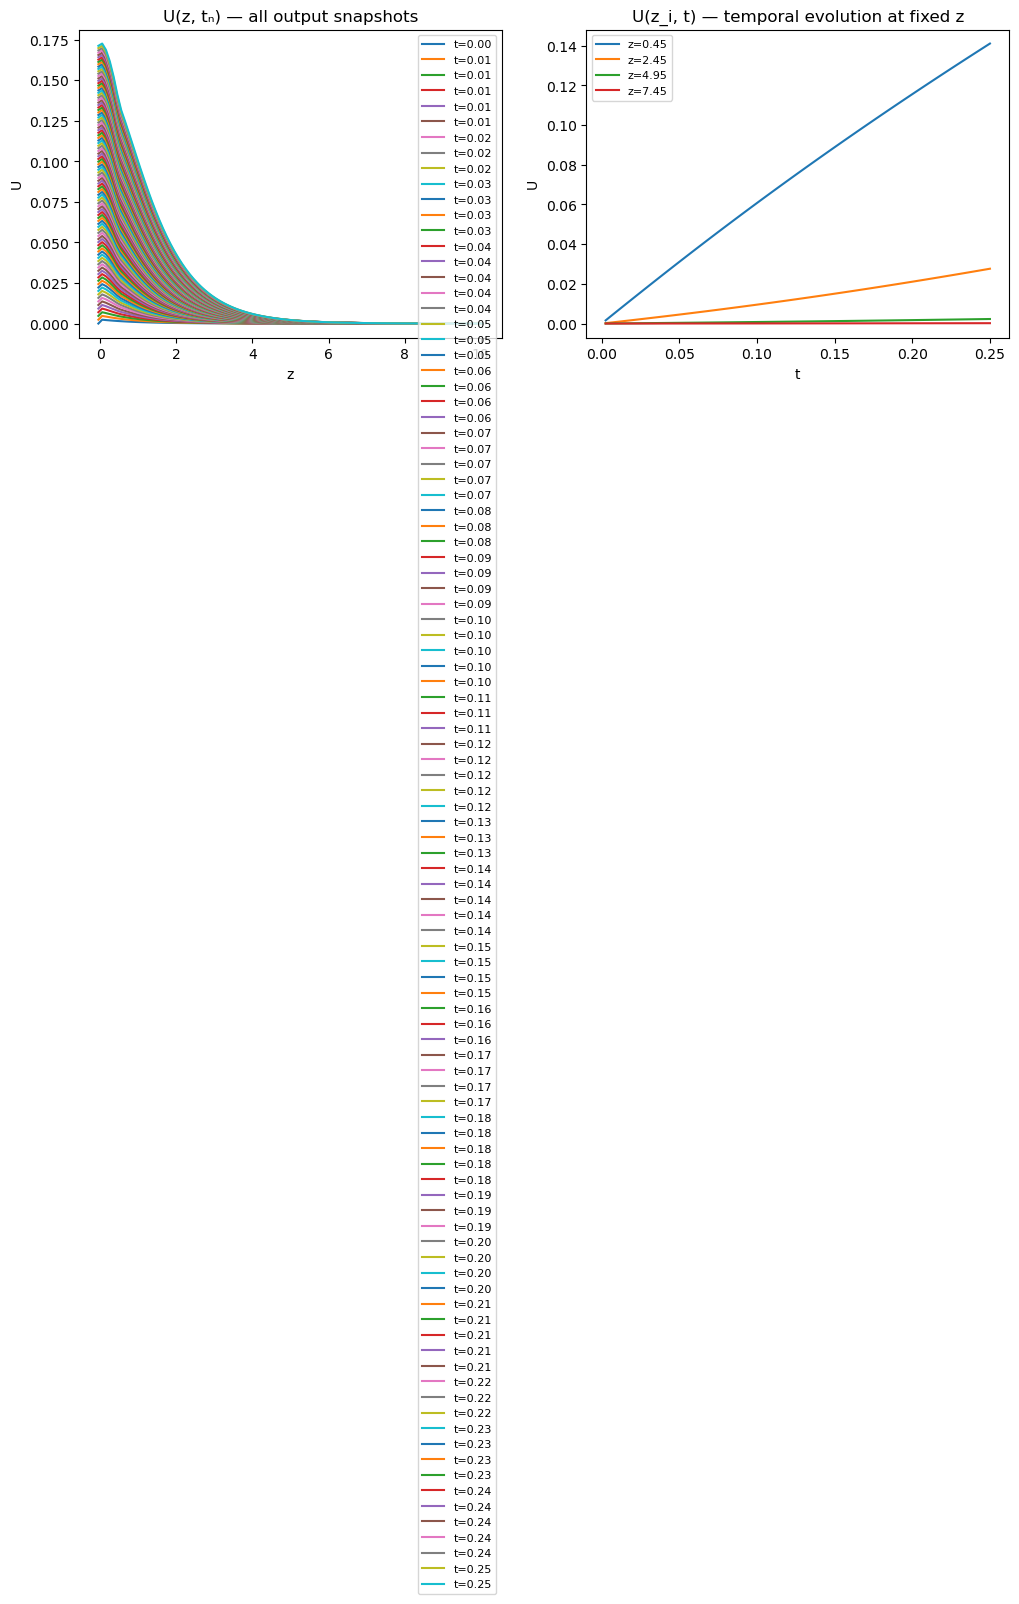

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# U(z) at each saved time
ax = axes[0]
for i, t_i in enumerate(t_out):
    ax.plot(z.numpy(), U[:, i].numpy(), label=f't={t_i:.2f}')
ax.set_xlabel('z'); ax.set_ylabel('U')
ax.set_title('U(z, tₙ) — all output snapshots')
ax.legend(fontsize=8)

# U(t) at a few z locations
ax = axes[1]
for iz in [5, nz//4, nz//2, 3*nz//4]:
    ax.plot(t_out.numpy(), U[iz, :].numpy(), label=f'z={z[iz]:.2f}')
ax.set_xlabel('t'); ax.set_ylabel('U')
ax.set_title('U(z_i, t) — temporal evolution at fixed z')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Save dataset

In [ ]:
import os; os.makedirs('./train', exist_ok=True)

n_out = t_out.shape[0]

data_to_save = {
    'z':       z,          # cell-edge grid      (nz+2,)
    'zh':      zh,         # cell-center grid    (nz+1,)
    't_out':   t_out,      # output times        (n_out,)
    'U':       U,          # solution field      (nz+2, n_out)
    'Delta_d': Delta_d,
    'k1':      k1,
    'k2':      k2,
    'kratio':  k1 / k2,
    'z_dis':   z_dis,
    'Pda':     Pda,
    'tf':      tf,
}

outfile = f'./train/2L_CN_nz{nz}_nout{n_out}_zc{z_dis}.pt'
torch.save(data_to_save, outfile)
print(f'Saved to {outfile}')
